## Dog Breed Classification

In this project we will use traditional CNN, CNN with data augmentation and finally transfer Learning by VGG16 model with weights pre-trained on Imagenet to solve the dog breed classification problem

### Load Dataset Files

In [0]:
#General Imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import time
import cv2
from zipfile import ZipFile

#SciKit Imports

from sklearn.preprocessing import LabelEncoder


#Keras Imports

from keras import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout
from keras.layers.normalization import BatchNormalization
from keras.utils import to_categorical
from keras.metrics import categorical_crossentropy
from keras import backend as K
from keras.preprocessing.image import ImageDataGenerator
from keras import Model

In [0]:
#Mounting Google Drive
#Loading Data
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [0]:
def unzip_files(fileName,path):
    """"
    This function takes the file name and path as parameters and unzips it
    It does not return anything.
    """
    print(path+fileName)
    with ZipFile(path+fileName,'r') as z:
        z.extractall()

Now, upload the given dataset file shared with you in your google drive and give its path for the below given `project_path` variable. For example, a path is given below according to the file path in our google drive. You need to change this to match the path of yours.

In [0]:
project_path = "/content/drive/My Drive/DogBreed_Classification/"

Run the below code to extract all the images in the train.zip files given in the dataset. We are going to use these images as train and validation sets and their labels in further steps.

In [0]:
unzip_files('train.zip',project_path) #unzip train data
print('Done unzipping train.zip....')

unzip_files('test.zip',project_path) #unzip train data
print('Done unzipping test.zip....')

unzip_files('sample_submission.csv.zip',project_path) #unzip train data
print('Done unzipping sample submission.zip....')

unzip_files('labels.csv.zip',project_path) #unzip train data
print('Done unzipping labels.zip....')

/content/drive/My Drive/DogBreed_Classification/train.zip
Done unzipping train.zip....
/content/drive/My Drive/DogBreed_Classification/test.zip
Done unzipping test.zip....
/content/drive/My Drive/DogBreed_Classification/sample_submission.csv.zip
Done unzipping sample submission.zip....
/content/drive/My Drive/DogBreed_Classification/labels.csv.zip
Done unzipping labels.zip....


After this process, we will have 4 files - Train folder, test folder and labels.csv and sample_submission.csv as part of your google drive

### Read labels.csv file using pandas

In [0]:
# We read the labels into a dataframe. The dataframe consists of files names and the class of the dog
name_to_label = pd.read_csv('labels.csv', names=['fileName','Breed'],header=0)
print('Read labels into DataFrame...Done...')
#The file name ends with a .jpg so adding that to the file name 
name_to_label['fileName'] = name_to_label['fileName'] + '.jpg'
print('Appended .jpg to file name....Done...')
#Setting the file name as the index of the dataframe
name_to_label.set_index(keys='fileName',inplace=True)
print('Set filename as index....Done...')


Read labels into DataFrame...Done...
Appended .jpg to file name....Done...
Set filename as index....Done...


In [0]:
name_to_label.head(3)

,Breed
fileName,
000bec180eb18c7604dcecc8fe0dba07.jpg,boston_bull
001513dfcb2ffafc82cccf4d8bbaba97.jpg,dingo
001cdf01b096e06d78e9e5112d419397.jpg,pekinese


### Print the count of each category of Dogs given in the dataset



In [0]:
pd.DataFrame(name_to_label['Breed'].value_counts())

,Breed
scottish_deerhound,126
maltese_dog,117
afghan_hound,116
entlebucher,115
bernese_mountain_dog,114
shih-tzu,112
great_pyrenees,111
pomeranian,111
basenji,110
samoyed,109


### Get one-hot encodings of labels

In [0]:
# First Convert labels to numeric - using sklearn's label encoder
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
lb.fit(name_to_label['Breed'])

LabelEncoder()

In [0]:
lb.classes_

array(['affenpinscher', 'afghan_hound', 'african_hunting_dog', 'airedale',
       'american_staffordshire_terrier', 'appenzeller',
       'australian_terrier', 'basenji', 'basset', 'beagle',
       'bedlington_terrier', 'bernese_mountain_dog',
       'black-and-tan_coonhound', 'blenheim_spaniel', 'bloodhound',
       'bluetick', 'border_collie', 'border_terrier', 'borzoi',
       'boston_bull', 'bouvier_des_flandres', 'boxer',
       'brabancon_griffon', 'briard', 'brittany_spaniel', 'bull_mastiff',
       'cairn', 'cardigan', 'chesapeake_bay_retriever', 'chihuahua',
       'chow', 'clumber', 'cocker_spaniel', 'collie',
       'curly-coated_retriever', 'dandie_dinmont', 'dhole', 'dingo',
       'doberman', 'english_foxhound', 'english_setter',
       'english_springer', 'entlebucher', 'eskimo_dog',
       'flat-coated_retriever', 'french_bulldog', 'german_shepherd',
       'german_short-haired_pointer', 'giant_schnauzer',
       'golden_retriever', 'gordon_setter', 'great_dane',
      

In [0]:
len(lb.classes_) # Notice that this is the same as the number of unique values

120

In [0]:
#Now converting them into numerical 
name_to_label['Breed_Numeric'] = lb.transform(name_to_label['Breed'])

In [0]:
name_to_label.head(3)

,Breed,Breed_Numeric
fileName,,
000bec180eb18c7604dcecc8fe0dba07.jpg,boston_bull,19
001513dfcb2ffafc82cccf4d8bbaba97.jpg,dingo,37
001cdf01b096e06d78e9e5112d419397.jpg,pekinese,85


In [0]:
#One hot coding using keras to_catergorical & save it in y_train
from keras.utils import to_categorical
y_train = to_categorical(name_to_label['Breed_Numeric'])

In [0]:
#Checking the one hot coding, this should a sparse matrix of 120 since there are 120 catergories
#y_train[0]

## Preparing training dataset
1. Write a code which reads each and every id from labels.csv file and loads the corresponding image (in RGB - 128, 128, 3) from the train folder. <br>
2. Create 2 variables <br> 
     a.  x_train - Should have all the images of the dogs from train folder <br>
     b.  y_train - Corresponding label of the dog <br>
<u>Note:</u> The id of the dog images and its corresponding labels are available in labels.csv file   
<u>Hint:</u> Watch the video shared on "Preparing the training dataset" if you face issue on creating the training dataset

In [0]:
# We will create 3 lists for the training data
# list_of_pictures_names , list_of_picture_labels , list_of_picture_vectors

path='./train/'

list_of_picture_names_train=[]
list_of_picture_labels_train=[]
list_of_picture_vectors_train=[]

for fileName in os.listdir('train'):
    list_of_picture_names_train.append(fileName)
    fN = path +fileName
    list_of_picture_vectors_train.append(cv2.resize(cv2.imread(fN),(128,128))) # cv2.imread converts image into a vector

print('Done creating two lists, one with file names and other with vector rep of image.')

Done creating two lists, one with file names and other with vector rep of image.


In [0]:
# Checking to see that the lengths are the same..
len(list_of_picture_names_train),len(list_of_picture_vectors_train)

(10222, 10222)

In [0]:
list_of_picture_vectors_train[0].shape

(128, 128, 3)

In [0]:
#Now creating a list of labels that are in the same order as the names list and vector lists

for name in list_of_picture_names_train:
    list_of_picture_labels_train.append(name_to_label.loc[name]['Breed'])
    
print('Done creating the list of picture labels in the same order as names and vector')

Done creating the list of picture labels in the same order as names and vector


Text(0.5, 1.0, 'norwegian_elkhound')

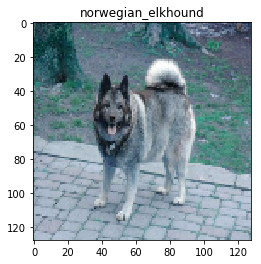

In [0]:
plt.imshow(list_of_picture_vectors_train[2])
plt.title(list_of_picture_labels_train[2])

In [0]:
from sklearn.preprocessing import LabelEncoder
lb = LabelEncoder()
lb.fit(list_of_picture_labels_train)
y_train = lb.transform(list_of_picture_labels_train)

In [0]:
y_train = to_categorical(y_train)

In [0]:
#y_train[0]

Normalize the training data and convert into 4 dimensions so that it can be used as an input to conv layers in the model

In [0]:
#Normalising the vectors

list_of_picture_vectors_train = [i/255 for i in list_of_picture_vectors_train] 

In [0]:
#Checking to see if the data is normalised & has the shape of 128x128 with 3 channels
list_of_picture_vectors_train[0].shape

(128, 128, 3)

### Split the training and validation data from `x_train` and `y_train` obtained from above step

In [0]:
#Converting the list of picture vectors /arrays into a 4 tensor & save it in X_train

X_train = np.array(list_of_picture_vectors_train)

In [0]:
X_train.shape , y_train.shape

((10222, 128, 128, 3), (10222, 120))

### Build a basic conv neural network with 2 conv layers (kernel sizes - 5 and 3) add layers as mentioned below for classification.

1. Add a Dense layer with 256 neurons with `relu` activation

2. Add a Dense layer with 120 neurons as final layer (as there are 120 classes in the given dataset) with `softmax` activation for classifiaction. 

In [0]:
K.clear_session()

model = Sequential()

model.add(Conv2D(32, (5, 5), activation='relu', input_shape=(128, 128, 3)))

model.add(Conv2D(64, (3, 3), activation='relu'))

model.add(Flatten())

model.add(Dense(256, activation='relu'))

model.add(Dense(120, activation='softmax'))

model.compile(loss='categorical_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

Instructions for updating:
Colocations handled automatically by placer.


In [0]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
conv2d_1 (Conv2D)            (None, 124, 124, 32)      2432      
_________________________________________________________________
conv2d_2 (Conv2D)            (None, 122, 122, 64)      18496     
_________________________________________________________________
flatten_1 (Flatten)          (None, 952576)            0         
_________________________________________________________________
dense_1 (Dense)              (None, 256)               243859712 
_________________________________________________________________
dense_2 (Dense)              (None, 120)               30840     
Total params: 243,911,480
Trainable params: 243,911,480
Non-trainable params: 0
_________________________________________________________________


### Use batch_size = 128 and epochs = 10 and execute the model

In [0]:
model.fit(X_train, y_train, batch_size=128,
          epochs=10, verbose=1, validation_split=0.1)

Instructions for updating:
Use tf.cast instead.
Train on 9199 samples, validate on 1023 samples
Epoch 1/10
9199/9199 [==============================] - 35s 4ms/step - loss: 15.7976 - acc: 0.0102 - val_loss: 15.8345 - val_acc: 0.0176
Epoch 2/10
9199/9199 [==============================] - 23s 3ms/step - loss: 15.9481 - acc: 0.0105 - val_loss: 15.8345 - val_acc: 0.0176
Epoch 3/10
9199/9199 [==============================] - 24s 3ms/step - loss: 15.9481 - acc: 0.0105 - val_loss: 15.8345 - val_acc: 0.0176
Epoch 4/10
9199/9199 [==============================] - 24s 3ms/step - loss: 15.9481 - acc: 0.0105 - val_loss: 15.8345 - val_acc: 0.0176
Epoch 5/10
9199/9199 [==============================] - 25s 3ms/step - loss: 15.9481 - acc: 0.0105 - val_loss: 15.8345 - val_acc: 0.0176
Epoch 6/10
9199/9199 [==============================] - 24s 3ms/step - loss: 15.9481 - acc: 0.0105 - val_loss: 15.8345 - val_acc: 0.0176
Epoch 7/10
9199/9199 [==============================] - 24s 3ms/step - loss: 15.94

#The model accuracy is very poor !!!!

### Use Data Augmentation in the above model to see if the accuracy improves


In [0]:
from keras.preprocessing.image import ImageDataGenerator

# This will do preprocessing and realtime data augmentation:
datagen = ImageDataGenerator(
    featurewise_center=False,  # set input mean to 0 over the dataset
    samplewise_center=False,  # set each sample mean to 0
    featurewise_std_normalization=False,  # divide inputs by std of the dataset
    samplewise_std_normalization=False,  # divide each input by its std
    zca_whitening=False,  # apply ZCA whitening
    rotation_range=50,  # randomly rotate images in the range (degrees, 0 to 180)
    width_shift_range=0.1,  # randomly shift images horizontally (fraction of total width)
    height_shift_range=0.1,  # randomly shift images vertically (fraction of total height)
    horizontal_flip=False,  # randomly flip images
    vertical_flip=False)  # randomly flip images

# Prepare the generator
datagen.fit(X_train)

In [0]:
model.fit_generator(datagen.flow(X_train, y_train,
                        batch_size=128),
                        steps_per_epoch=len(X_train),
                        nb_epoch=10)


Instructions for updating:
Use tf.cast instead.


/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: UserWarning: The semantics of the Keras 2 argument `steps_per_epoch` is not the same as the Keras 1 argument `samples_per_epoch`. `steps_per_epoch` is the number of batches to draw from the generator at each epoch. Basically steps_per_epoch = samples_per_epoch/batch_size. Similarly `nb_val_samples`->`validation_steps` and `val_samples`->`steps` arguments have changed. Update your method calls accordingly.
  after removing the cwd from sys.path.
/usr/local/lib/python3.6/dist-packages/ipykernel_launcher.py:4: UserWarning: Update your `fit_generator` call to the Keras 2 API: `fit_generator(<keras_pre..., steps_per_epoch=10222, epochs=10)`
  after removing the cwd from sys.path.


Epoch 1/10


# Model accuracy is still poor!!!

### Lets use Transfer Learning

Download the vgg wieght file from here : https://github.com/MinerKasch/applied_deep_learning/blob/master/vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5

Use the below code to load VGG16 weights trained on ImageNet

In [0]:
K.clear_session()
project_path = '/content/drive/My Drive/'
from keras.applications.vgg16 import VGG16, preprocess_input
# Instantiate the model with the pre-trained weights (no top)
base_model= VGG16(weights= project_path+'vgg16_weights_tf_dim_ordering_tf_kernels_notop.h5',
                 include_top=False, pooling='avg',input_shape = (128, 128, 3))
  
#base_model= VGG16(weights='imagenet',
 #                include_top=False, pooling='avg',input_shape = (128, 128, 3))

In [0]:
base_model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
input_1 (InputLayer)         (None, 128, 128, 3)       0         
_________________________________________________________________
block1_conv1 (Conv2D)        (None, 128, 128, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 128, 128, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 64, 64, 64)        0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 64, 64, 128)       73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 64, 64, 128)       147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 32, 32, 128)       0         
__________

Print the summary of the base_model

In [0]:
base_model.layers.pop()

### Add the following classification layers to the imported VGG Model <br>
1. Flatten Layer
2. Dense layer with 1024 neurons with activation as Relu
3. Dense layer with 256 neurons with activation as Relu
4. Dense layer with 120 neurons with activation as Softmax

In [0]:
# We can create a sequencial model as usual and add the layers from the VGG model
model = Sequential()

# Adding the VCG layers
for lay in base_model.layers:
    model.add(lay)

#Customising by adding our own set of layers
model.add(Flatten())
model.add(Dense(1024, activation='relu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))
model.add(Dense(256, activation='relu'))
model.add(Dense(120, activation='softmax'))

Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


In [0]:
model.summary()

_________________________________________________________________
Layer (type)                 Output Shape              Param #   
block1_conv1 (Conv2D)        (None, 128, 128, 64)      1792      
_________________________________________________________________
block1_conv2 (Conv2D)        (None, 128, 128, 64)      36928     
_________________________________________________________________
block1_pool (MaxPooling2D)   (None, 64, 64, 64)        0         
_________________________________________________________________
block2_conv1 (Conv2D)        (None, 64, 64, 128)       73856     
_________________________________________________________________
block2_conv2 (Conv2D)        (None, 64, 64, 128)       147584    
_________________________________________________________________
block2_pool (MaxPooling2D)   (None, 32, 32, 128)       0         
_________________________________________________________________
block3_conv1 (Conv2D)        (None, 32, 32, 256)       295168    
__________

### Make all the layers in the base_model (VGG16) to be non-trainable

In [0]:
for lay in model.layers:
  if(lay.name[0:5]=='block'):
    lay.trainable = False

### Fit and compile the model with batch_size = 128 and epochs = 10 and execute the model

Try to get training and validation accuracy to be more than 90%

In [0]:
model.compile(loss='categorical_crossentropy',
              optimizer='rmsprop',
              metrics=['accuracy'])

In [0]:
model.fit(X_train, y_train, batch_size=128,
          epochs=20, verbose=1, validation_split=0.1)

Train on 9199 samples, validate on 1023 samples
Epoch 1/20
9199/9199 [==============================] - 26s 3ms/step - loss: 1.3625 - acc: 0.7508 - val_loss: 5.0322 - val_acc: 0.2160
Epoch 2/20
9199/9199 [==============================] - 19s 2ms/step - loss: 0.8400 - acc: 0.7972 - val_loss: 4.7100 - val_acc: 0.2248
Epoch 3/20
9199/9199 [==============================] - 18s 2ms/step - loss: 0.6061 - acc: 0.8406 - val_loss: 4.7780 - val_acc: 0.2151
Epoch 4/20
9199/9199 [==============================] - 18s 2ms/step - loss: 0.4505 - acc: 0.8741 - val_loss: 4.9788 - val_acc: 0.2199
Epoch 5/20
9199/9199 [==============================] - 18s 2ms/step - loss: 0.3488 - acc: 0.9000 - val_loss: 5.0769 - val_acc: 0.2209
Epoch 6/20
9199/9199 [==============================] - 19s 2ms/step - loss: 0.3076 - acc: 0.9123 - val_loss: 5.4419 - val_acc: 0.2063
Epoch 7/20
9199/9199 [==============================] - 19s 2ms/step - loss: 0.2635 - acc: 0.9214 - val_loss: 5.2920 - val_acc: 0.2414
Epoch 8